In [128]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.svm import SVC
from sklearn.metrics import *
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import *
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn import *
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from numpy import argmax
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from yellowbrick.classifier import ROCAUC, ClassificationReport, PrecisionRecallCurve

In [3]:
X, y = make_classification(n_samples=1000, n_classes=2, random_state=1)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=2)

In [7]:
model = LogisticRegression().fit(X_train, y_train)

In [8]:
y_pred_proba = model.predict_proba(X_test)

In [9]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba[:, 1])

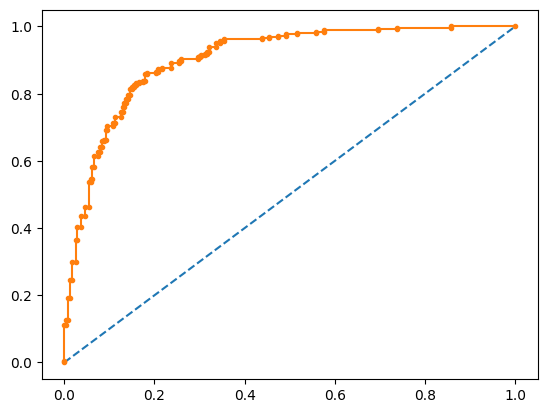

In [10]:
plt.plot([0, 1], [0, 1], linestyle='--')
plt.plot(fpr, tpr, marker='.')
plt.show()

In [11]:
roc_auc_score(y_test, y_pred_proba[:, 1])

0.9027724358974359

In [12]:
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba[:, 1])

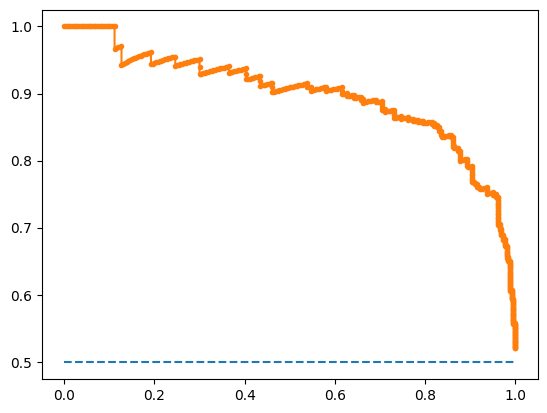

In [14]:
no_skill = len(y[y==1]) / len(y)
plt.plot([0, 1], [no_skill, no_skill], linestyle='--')

plt.plot(recall, precision, marker='.')
plt.show()

In [15]:
auc(recall, precision)

0.897662372903334

In [16]:
y_test_pred = model.predict(X_test)
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.83      0.82      0.83       240
           1       0.84      0.85      0.84       260

    accuracy                           0.83       500
   macro avg       0.83      0.83      0.83       500
weighted avg       0.83      0.83      0.83       500



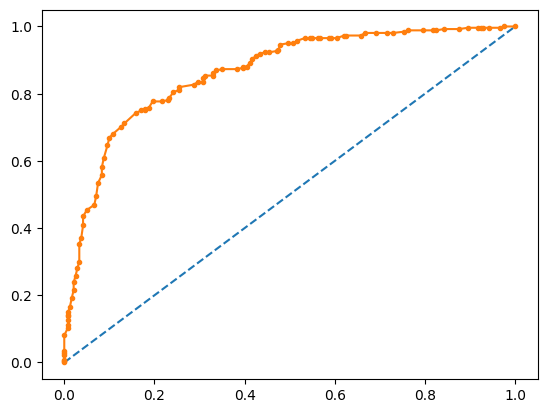

In [19]:
model2 = KNeighborsClassifier(n_neighbors=250).fit(X_train, y_train)
y_pred2_proba = model2.predict_proba(X_test)
fpr, tpr, _ = roc_curve(y_test, y_pred2_proba[:, 1])

plt.plot([0, 1], [0, 1], linestyle='--')
plt.plot(fpr, tpr, marker='.')
plt.show()

In [20]:
roc_auc_score(y_test, y_pred2_proba[:, 1])

0.8630608974358974

In [21]:
X, y = make_classification(n_samples=1000, n_classes=2, weights=[0.99, 0.01], random_state=1)

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=4)

print('Датасет: Class0=%d, Class1=%d' % (len(y[y==0]), len(y[y==1])))
print('Обучающая: Class0=%d, Class1=%d' % (len(y_train[y_train==0]), len(y_train[y_train==1])))
print('Тестовая: Class0=%d, Class1=%d' % (len(y_test[y_test==0]), len(y_test[y_test==1])))

Датасет: Class0=985, Class1=15
Обучающая: Class0=490, Class1=10
Тестовая: Class0=495, Class1=5


In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, stratify=y)

In [32]:
model = LogisticRegression().fit(X_train, y_train)
y_pred_proba = model.predict_proba(X_test)

In [33]:
y_test_pred = model.predict(X_test)
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       492
           1       0.00      0.00      0.00         8

    accuracy                           0.98       500
   macro avg       0.49      0.50      0.50       500
weighted avg       0.97      0.98      0.98       500



/opt/homebrew/Cellar/jupyterlab/4.4.10/libexec/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Cellar/jupyterlab/4.4.10/libexec/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Cellar/jupyterlab/4.4.10/libexec/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

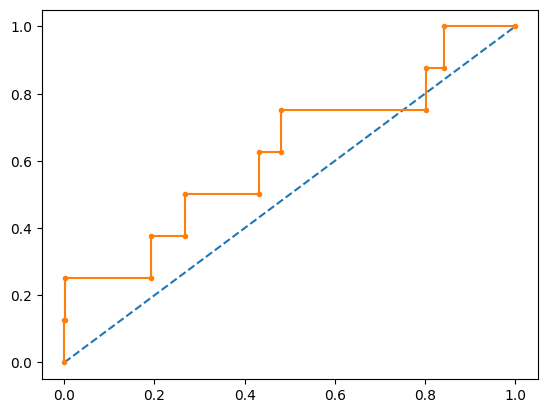

In [34]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba[:, 1])

plt.plot([0, 1], [0, 1], linestyle='--')
plt.plot(fpr, tpr, marker='.')
plt.show()

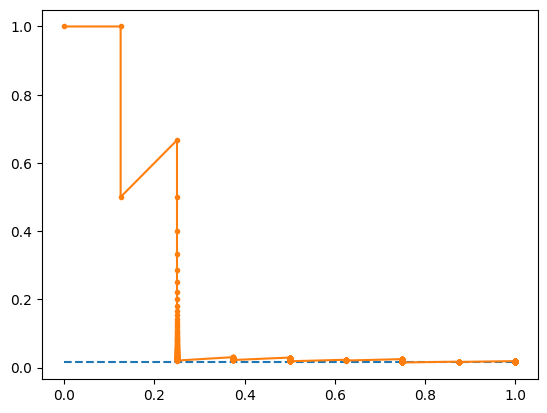

In [35]:
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba[:, 1])
no_skill = len(y[y==1]) / len(y)
plt.plot([0, 1], [no_skill, no_skill], linestyle='--')
plt.plot(recall, precision, marker='.')
plt.show()

In [36]:
X, y = make_classification(n_samples=10000, n_classes=2, weights=[0.99, 0.01], random_state=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, stratify=y)

model = LogisticRegression().fit(X_train, y_train)
y_pred_proba = model.predict_proba(X_test)

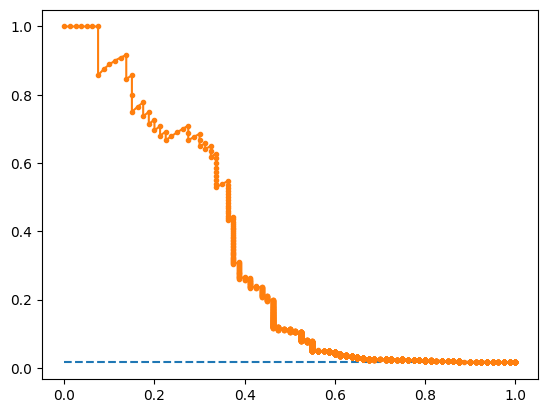

In [37]:
p, r, pr_thresholds = precision_recall_curve(y_test, y_pred_proba[:, 1])
no_skill = len(y[y==1]) / len(y)
plt.plot([0, 1], [no_skill, no_skill], linestyle='--')
plt.plot(r, p, marker='.')
plt.show()

In [39]:
f1 = (2 * p * r) / (p + r)
ix = argmax(f1)
pr_thresholds[ix]

np.float64(0.1746831026521508)

In [40]:
print('Порог=%f, F-Score=%.3f' % (pr_thresholds[ix], f1[ix]))

Порог=0.174683, F-Score=0.439


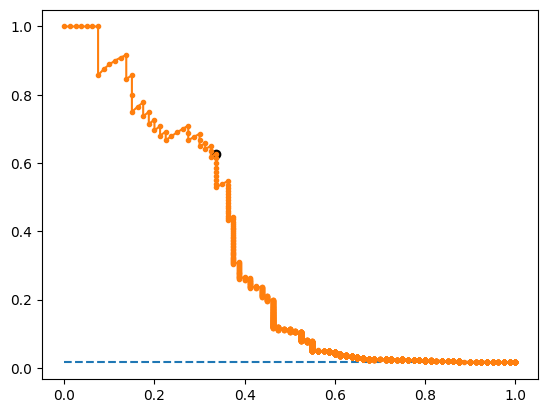

In [41]:
plt.plot([0, 1], [no_skill, no_skill], linestyle='--')
plt.plot(r, p, marker='.')
plt.scatter(r[ix], p[ix], marker='o', color='black')
plt.show()

In [42]:
y_pred = (y_pred_proba[:, 1] > pr_thresholds[ix]).astype('int')

In [43]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      4920
           1       0.62      0.33      0.43        80

    accuracy                           0.99      5000
   macro avg       0.80      0.66      0.71      5000
weighted avg       0.98      0.99      0.98      5000



In [44]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      4920
           1       0.90      0.11      0.20        80

    accuracy                           0.99      5000
   macro avg       0.94      0.56      0.60      5000
weighted avg       0.98      0.99      0.98      5000



## Практическая работа

### 1. Двумерный датасет

In [63]:
X, y = make_classification(n_samples=1000, n_features=2, n_redundant=0, n_clusters_per_class=1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=2)

In [64]:
model = LogisticRegression().fit(X_train, y_train)
y_proba = model.predict_proba(X_test)[:, 1]

In [65]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

In [66]:
thresholds_to_plot = [0.3, 0.5, 0.7]

x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05), np.arange(y_min, y_max, 0.05))

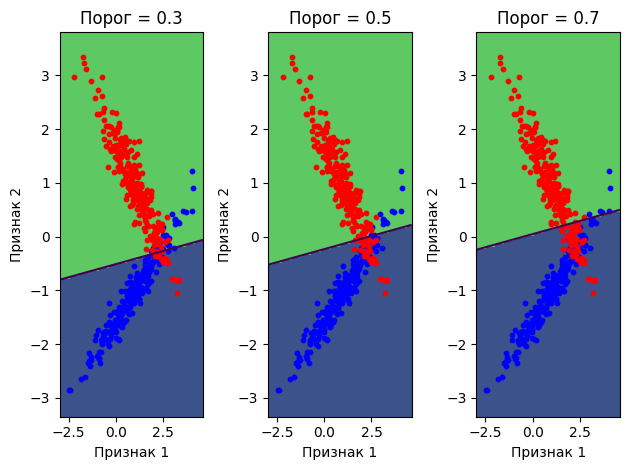

(None, None)

In [77]:
for i, thr in enumerate(thresholds_to_plot, 1):
    plt.subplot(1, 3, i)
    
    Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)
    
    plt.contourf(xx, yy, Z > thr)
    plt.contour(xx, yy, Z, [thr])
    
    for c, label in zip(['blue', 'red'], [0, 1]):
        plt.scatter(*X_test[y_test==label].T, c=c, s=10)
    
    plt.title(f'Порог = {thr}'), plt.xlabel('Признак 1'), plt.ylabel('Признак 2')

plt.tight_layout(), plt.show()

### 2. Анализ на датасете для бин классификации

In [78]:
data = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/main/ML4.1%20metrics/data/heart.csv')
X = data.drop('output', axis=1)
y = data['output']

In [79]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [80]:
model = LogisticRegression(max_iter=1000).fit(X_train_scaled, y_train)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

In [81]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

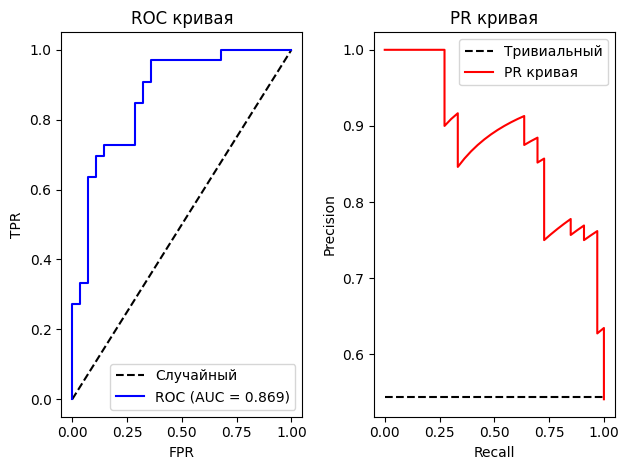

In [83]:
plt.subplot(1, 2, 1)
plt.plot([0, 1], [0, 1], 'k--', label='Случайный')
plt.plot(fpr, tpr, 'b-', label=f'ROC (AUC = {roc_auc_score(y_test, y_proba):.3f})')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC кривая')
plt.legend()

plt.subplot(1, 2, 2)
no_skill = len(y[y==1]) / len(y)
plt.plot([0, 1], [no_skill, no_skill], 'k--', label='Тривиальный')
plt.plot(recall, precision, 'r-', label='PR кривая')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR кривая')
plt.legend()

plt.tight_layout()
plt.show()

In [84]:
f1 = 2 * precision * recall / (precision + recall + 1e-10)
best_idx = np.argmax(f1)
best_thr = thresholds[best_idx]

In [85]:
y_pred_default = model.predict(X_test_scaled)
y_pred_best = (y_proba > best_thr).astype(int)

In [86]:
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}')
print(f'\nПорог по умолчанию (0.5):')
print(classification_report(y_test, y_pred_default))
print(f'\nОптимальный порог ({best_thr:.3f}):')
print(classification_report(y_test, y_pred_best))

ROC-AUC: 0.869

Порог по умолчанию (0.5):
              precision    recall  f1-score   support

           0       0.86      0.68      0.76        28
           1       0.77      0.91      0.83        33

    accuracy                           0.80        61
   macro avg       0.82      0.79      0.80        61
weighted avg       0.81      0.80      0.80        61


Оптимальный порог (0.256):
              precision    recall  f1-score   support

           0       0.90      0.64      0.75        28
           1       0.76      0.94      0.84        33

    accuracy                           0.80        61
   macro avg       0.83      0.79      0.79        61
weighted avg       0.82      0.80      0.80        61



**ROC-AUC = 0.869** — модель хорошо разделяет классы.

**Влияние порога:**
- **Порог 0.5 (по умолчанию):** recall класса 1 = 0.91 — выявляет 91% больных
- **Порог 0.256 (оптимальный):** recall класса 1 = 0.94 — выявляет **94% больных**

Снижение порога увеличивает чувствительность (recall) к положительному классу, что важно для медицинских задач — лучше выявить больше больных, даже с риском ложных срабатываний. Оптимальный порог зависит от цели: минимизировать пропуски → выбирать порог ниже.

### 3. Критерии оптимизации

In [88]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

In [90]:
g_mean = np.sqrt(tpr * (1 - fpr))
best_idx = np.argmax(g_mean)
best_thr = thresholds[best_idx]

In [91]:
y_pred_default = model.predict(X_test_scaled)
y_pred_best = (y_proba > best_thr).astype(int)

In [92]:
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}')
print(f'Оптимальный порог (по G-mean): {best_thr:.3f}')
print(f'TPR = {tpr[best_idx]:.3f}, FPR = {fpr[best_idx]:.3f}, G-mean = {g_mean[best_idx]:.3f}')

print('\nПорог по умолчанию (0.5):')
print(classification_report(y_test, y_pred_default))

print(f'\nОптимальный порог ({best_thr:.3f}):')
print(classification_report(y_test, y_pred_best))

ROC-AUC: 0.869
Оптимальный порог (по G-mean): 0.722
TPR = 0.727, FPR = 0.143, G-mean = 0.790

Порог по умолчанию (0.5):
              precision    recall  f1-score   support

           0       0.86      0.68      0.76        28
           1       0.77      0.91      0.83        33

    accuracy                           0.80        61
   macro avg       0.82      0.79      0.80        61
weighted avg       0.81      0.80      0.80        61


Оптимальный порог (0.722):
              precision    recall  f1-score   support

           0       0.71      0.86      0.77        28
           1       0.85      0.70      0.77        33

    accuracy                           0.77        61
   macro avg       0.78      0.78      0.77        61
weighted avg       0.78      0.77      0.77        61



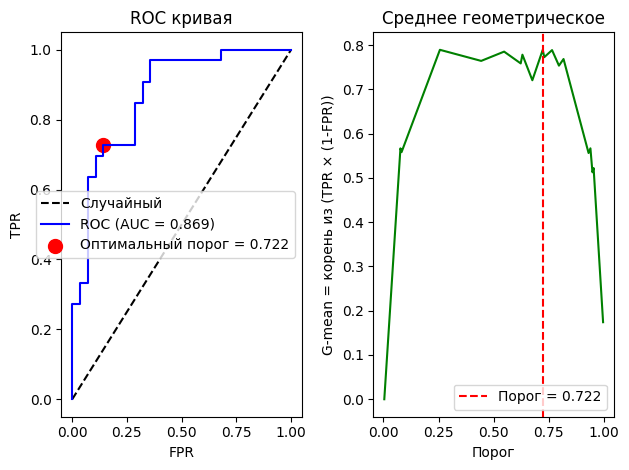

In [97]:
plt.subplot(1, 2, 1)
plt.plot([0, 1], [0, 1], 'k--', label='Случайный')
plt.plot(fpr, tpr, 'b-', label=f'ROC (AUC = {roc_auc_score(y_test, y_proba):.3f})')
plt.scatter(fpr[best_idx], tpr[best_idx], color='red', s=100, label=f'Оптимальный порог = {best_thr:.3f}')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC кривая')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(thresholds, g_mean, 'g-')
plt.axvline(best_thr, color='red', linestyle='--', label=f'Порог = {best_thr:.3f}')
plt.xlabel('Порог')
plt.ylabel('G-mean = корень из (TPR × (1-FPR))')
plt.title('Среднее геометрическое')
plt.legend()

plt.tight_layout()
plt.show()

### 4. Другая метрика с разными превалированиями 

In [99]:
data = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/main/ML4.1%20metrics/data/heart.csv')
X = data.drop('output', axis=1)
y = data['output']

In [100]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [101]:
model = LogisticRegression(max_iter=1000).fit(X_train_scaled, y_train)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

In [105]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
precision = precision[:-1]
recall = recall[:-1]

In [106]:
f_prec = (1 + 0.5**2) * (precision * recall) / ((0.5**2 * precision) + recall + 1e-10)
f_rec = (1 + 2**2) * (precision * recall) / ((2**2 * precision) + recall + 1e-10)

In [107]:
best_prec = thresholds[np.argmax(f_prec)]
best_rec = thresholds[np.argmax(f_rec)]

In [108]:
y_pred_prec = (y_proba > best_prec).astype(int)
y_pred_rec = (y_proba > best_rec).astype(int)

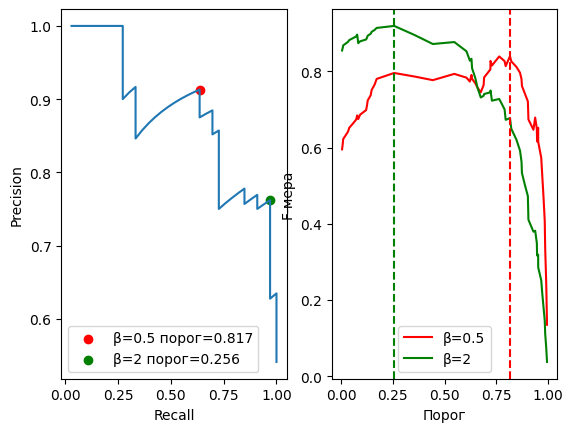

In [109]:
plt.subplot(1, 2, 1)
plt.plot(recall, precision)
plt.scatter(recall[np.argmax(f_prec)], precision[np.argmax(f_prec)], color='red', label=f'β=0.5 порог={best_prec:.3f}')
plt.scatter(recall[np.argmax(f_rec)], precision[np.argmax(f_rec)], color='green', label=f'β=2 порог={best_rec:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(thresholds, f_prec, 'r-', label='β=0.5')
plt.plot(thresholds, f_rec, 'g-', label='β=2')
plt.axvline(best_prec, color='red', linestyle='--')
plt.axvline(best_rec, color='green', linestyle='--')
plt.xlabel('Порог')
plt.ylabel('F-мера')
plt.legend()
plt.show()

### 5. Классификационные кривые для мн классиф

In [111]:
iris = load_iris()
X = iris.data
y = iris.target

In [114]:
y_bin = label_binarize(y, classes=[0, 1, 2])

In [115]:
X_train, X_test, y_train, y_test = train_test_split(X, y_bin, test_size=0.3, random_state=42)

In [118]:
model = OneVsRestClassifier(LogisticRegression(max_iter=1000))
model.fit(X_train, y_train)
y_proba = model.predict_proba(X_test)

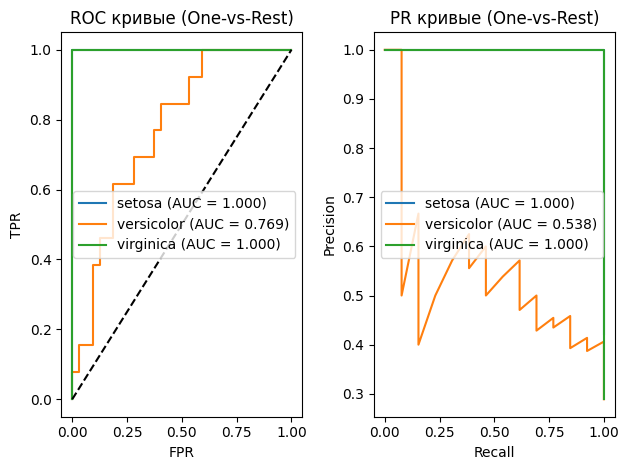

In [119]:
plt.subplot(1, 2, 1)
for i in range(3):
    fpr, tpr, _ = roc_curve(y_test[:, i], y_proba[:, i])
    auc_score = roc_auc_score(y_test[:, i], y_proba[:, i])
    plt.plot(fpr, tpr, label=f'{iris.target_names[i]} (AUC = {auc_score:.3f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC кривые (One-vs-Rest)')
plt.legend()

plt.subplot(1, 2, 2)
for i in range(3):
    precision, recall, _ = precision_recall_curve(y_test[:, i], y_proba[:, i])
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f'{iris.target_names[i]} (AUC = {pr_auc:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR кривые (One-vs-Rest)')
plt.legend()

plt.tight_layout()
plt.show()

In [120]:
roc_auc_macro = roc_auc_score(y_test, y_proba, average='macro')
roc_auc_weighted = roc_auc_score(y_test, y_proba, average='weighted')

print(f'ROC-AUC (macro): {roc_auc_macro:.3f}')
print(f'ROC-AUC (weighted): {roc_auc_weighted:.3f}')

ROC-AUC (macro): 0.923
ROC-AUC (weighted): 0.933


### 6. Библиотека yellowbrick

In [121]:
iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

In [122]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [124]:
model = LogisticRegression(max_iter=1000)

In [142]:
plt.figure(figsize=(3, 3))

<Figure size 300x300 with 0 Axes>

<Figure size 300x300 with 0 Axes>

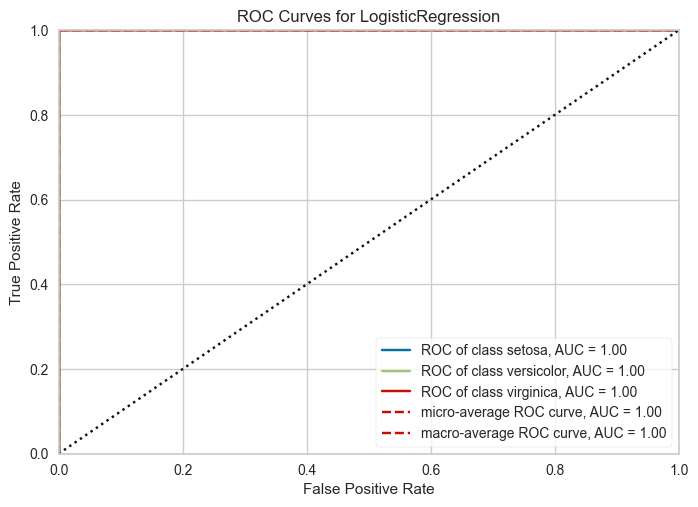

<Axes: title={'center': 'ROC Curves for LogisticRegression'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [143]:
visualizer_roc = ROCAUC(model, classes=target_names, micro=True, macro=True, per_class=True)
visualizer_roc.fit(X_train, y_train)
visualizer_roc.score(X_test, y_test)
visualizer_roc.show()

/opt/homebrew/Cellar/jupyterlab/4.4.10/libexec/lib/python3.14/site-packages/yellowbrick/classifier/prcurve.py:254: YellowbrickWarning: micro=True is ignored;specify per_class=False to draw a PR curve after micro-averaging
  warnings.warn(


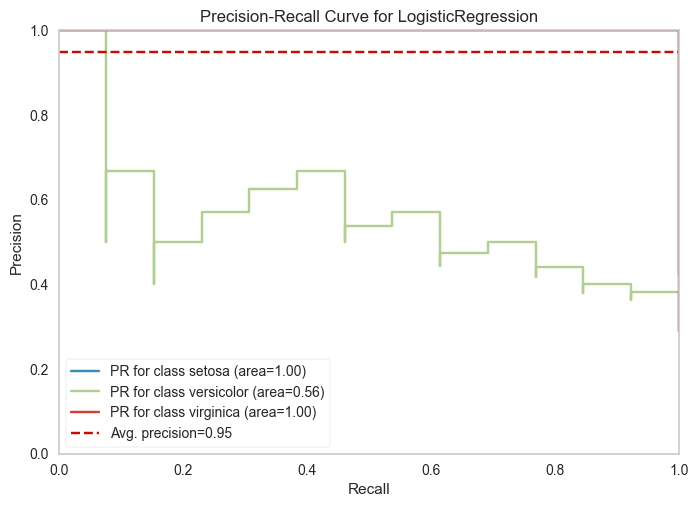

<Axes: title={'center': 'Precision-Recall Curve for LogisticRegression'}, xlabel='Recall', ylabel='Precision'>

In [144]:
visualizer_pr = PrecisionRecallCurve(model, classes=target_names, micro=True, per_class=True, ap_score=True)
visualizer_pr.fit(X_train, y_train)
visualizer_pr.score(X_test, y_test)
visualizer_pr.show()

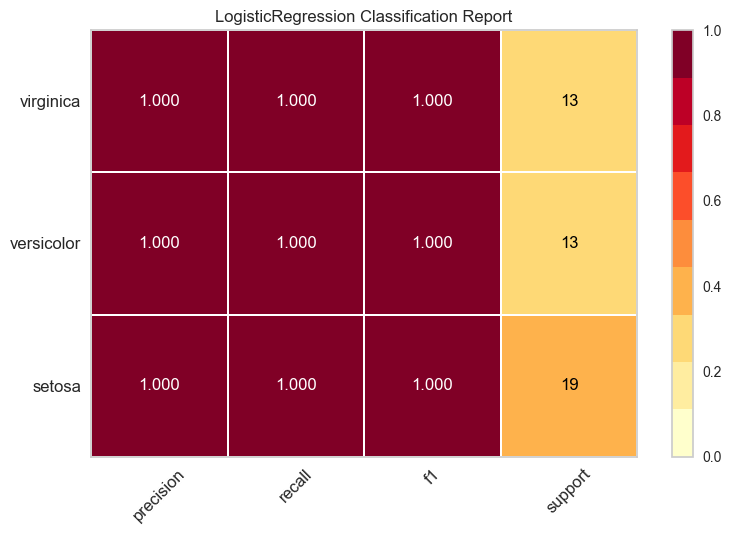

<Axes: title={'center': 'LogisticRegression Classification Report'}>

In [145]:
visualizer_cr = ClassificationReport(model, classes=target_names, support=True)
visualizer_cr.fit(X_train, y_train)
visualizer_cr.score(X_test, y_test)
visualizer_cr.show()